In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from tqdm import tqdm

# Data Cleaning

In [292]:
#Loading Data
df = pd.read_csv("squirrel.csv")
df.drop(columns=["Unique Squirrel ID", "Color notes", "Specific Location", "Lat/Long", "Combination of Primary and Highlight Color"], inplace=True)
#Unique Squirrel ID, Lat/Long and Combination of Primary and Highlight Color are redundant,
#"Color notes", "Specific Location" has too many nulls

#Standardise Data
df["Age"] = df["Age"].replace('?', np.nan) #assumes ? means nan
df["Date"] = pd.to_datetime(df['Date'].astype(str), format='%m%d%Y')
#df['Day'] = df["Date"].dt.day
df['Above Ground Sighter Measurement'] = df['Above Ground Sighter Measurement'].replace('FALSE', '0').astype("float64") #assumes False means 0
#could optionally parse Other Activities and Other Interactions

#Additional Features
df["HectareSN"] = df['Hectare'].str[:2].astype(int)
df["HectareWE"] = df['Hectare'].str[2:].apply(lambda x: ord(x.lower()) - 96)
#df['DayOfWeek'] = df['Date'].dt.dayofweek
#df['is_weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

#df['OA_Desc_Length'] = df['Other Activities'].str.split().str.len().fillna(0)
#df['OA_Interaction_Count'] = df['Other Activities'].str.findall(r'#(\d+)').apply(lambda x: len(set(x)) if isinstance(x, list) else 0) #unique interactions
#df['OI_Desc_Length'] = df['Other Activities'].str.split().str.len().fillna(0)
#could optionally parse Other Activities and Other Interactions
df.drop(columns=["Date", "Other Activities", "Other Interactions"], inplace=True)
#print(df.info())

In [293]:
#Target
TARGET = "Shift"

#Missing Data
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
if TARGET in obj_cols: obj_cols.remove(TARGET)
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().replace('', np.nan)
df[obj_cols] = df[obj_cols].fillna('nan')

num_cols = df.select_dtypes(include=['number']).columns.tolist()
if TARGET in num_cols: num_cols.remove(TARGET)
for col in num_cols:
    df[f'{col}_is_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median()) #could use model-based impute instead

bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
if TARGET in bool_cols: bool_cols.remove(TARGET)
for col in bool_cols:
    df[f'{col}_is_missing'] = df[col].isna().astype(int)
    df[col] = df[col].astype(float).fillna(0)
#assumes nan means 0
#adds missing flags to find signals in missingness and prevent imputation bias

#Encoding
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    df[col] = df[col].astype('category').cat.codes
#used label encoding despite implying false order as it is better for tree-based models
#one-hot enoding may lead to feature fragmentation

#Features
behaviour_cols = bool_cols + ["Age", "Location"] + ["Shift"]# + ["is_weekend"]
day_cols = ["Day", "DayOfWeek"]
coords = ["X", "Y"]

# 1. Does a squirrel's location within Central Park influence its behavioural patterns, and can we identify distinct spatial zones in the park that correspond to specific behaviours such as foraging, running, or eating?



Spatial Plots

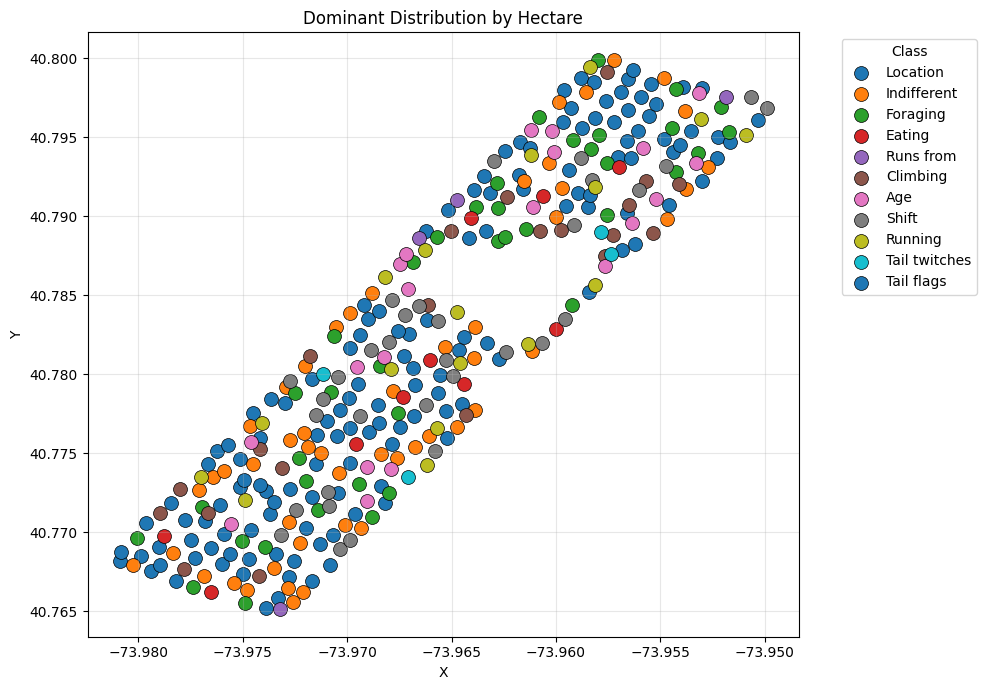

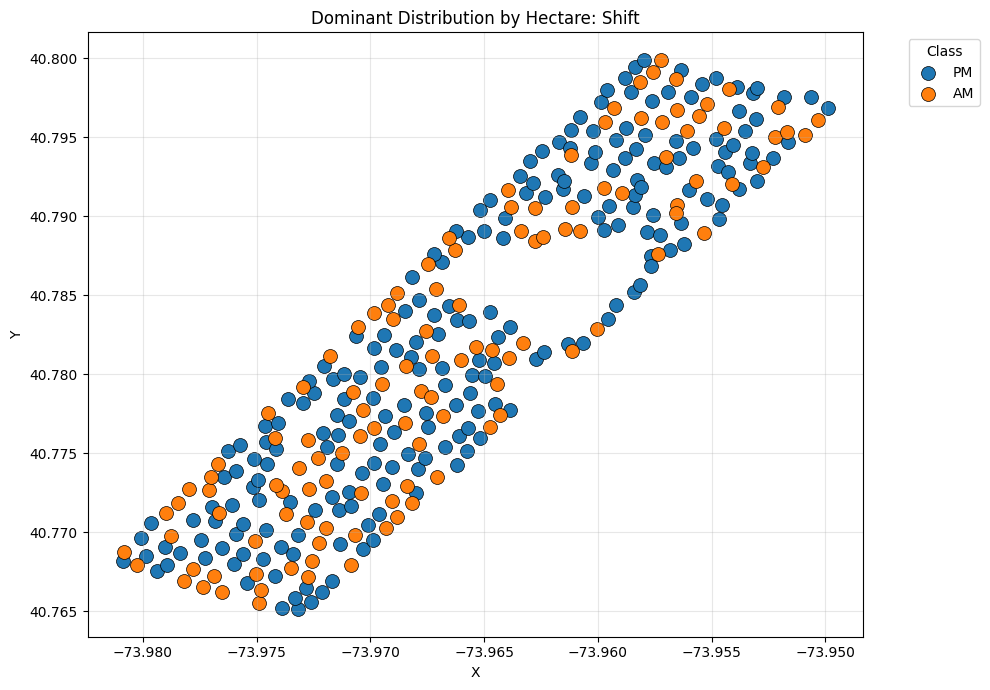

In [294]:
def location_plot(df, hue_col):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='X', y='Y', hue=hue_col, palette='tab20', s=20, alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"Location ({hue_col})")
    plt.tight_layout()
    plt.show()

def plot_spatial_grid(df, behavioural_cols, lat_col="X", lon_col="Y", group_col="Hectare", labels=["0", "1"]):
    if isinstance(behavioural_cols, str):
        temp_df = df.copy()
        temp_df[labels[1]] = (temp_df[behavioural_cols] > 0.5).astype(int)
        temp_df[labels[0]] = (temp_df[behavioural_cols] <= 0.5).astype(int)
        active_cols = [labels[1], labels[0]]
        title_suffix = f": {behavioural_cols}"
    else:
        temp_df = df
        active_cols = behavioural_cols
        title_suffix = ""

    plot_cols = active_cols + [lat_col, lon_col]
    data = temp_df.groupby(group_col)[plot_cols].mean()
    data["dominant"] = data[active_cols].idxmax(axis=1)

    plt.figure(figsize=(10, 7))
    for label in data["dominant"].unique():
        mask = data["dominant"] == label
        plt.scatter(data.loc[mask, lat_col], data.loc[mask, lon_col], label=label, s=100, edgecolor='black', linewidth=0.5)

    plt.title(f"Dominant Distribution by {group_col}{title_suffix}")
    plt.xlabel(lat_col)
    plt.ylabel(lon_col)
    plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def new_cluster(df, input_cols, target_col, name, n=10, ADD=True):
    temp_df = df.copy()
    cluster_col = f'{name}_cluster'
    stat_col = f'{name}_cluster_{target_col}_mean'

    km = KMeans(n_clusters=n, n_init=10, random_state=42)
    cluster_labels = km.fit_predict(temp_df[input_cols])

    temp_df[cluster_col] = cluster_labels
    temp_df[stat_col] = temp_df.groupby(cluster_col)[target_col].transform('mean')

    if ADD:
        dist_matrix = km.transform(temp_df[input_cols])
        temp_df[f'{name}_dist_to_center'] = dist_matrix[np.arange(len(dist_matrix)), cluster_labels]
        temp_df[f'{name}_cluster_density'] = temp_df[cluster_col].map(temp_df[cluster_col].value_counts())
    return temp_df


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

plot_spatial_grid(df, behaviour_cols, group_col="Hectare")
plot_spatial_grid(df, "Shift", group_col="Hectare", labels=["AM", "PM"])
"""
for col in behaviour_cols:
  if col == "Shift": continue
  plot_spatial_grid(df, col, group_col="Hectare")
"""

df = new_cluster(df, coords, TARGET, "Geo")
#plot_spatial_grid(df, behaviour_cols, group_col="Geo_cluster")
#plot_spatial_grid(df, "Shift", group_col="Geo_cluster", labels=["AM", "PM"])


Relationship Exploration

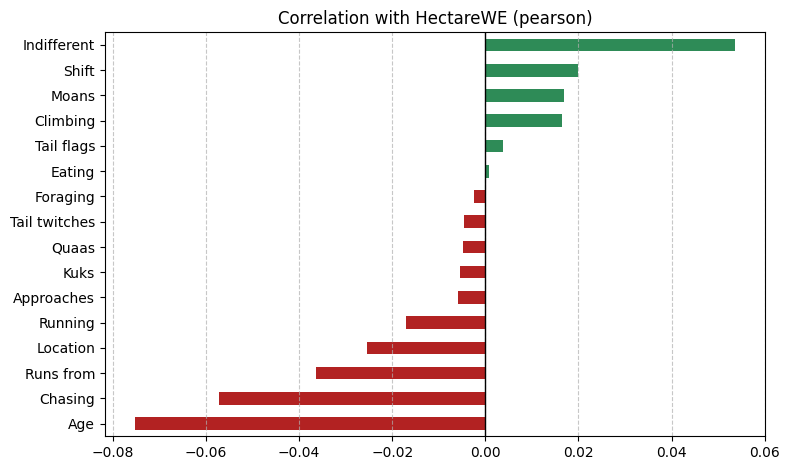

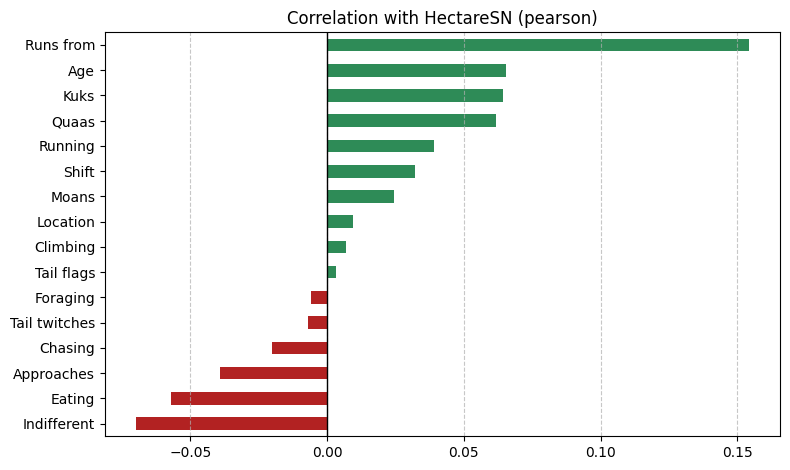

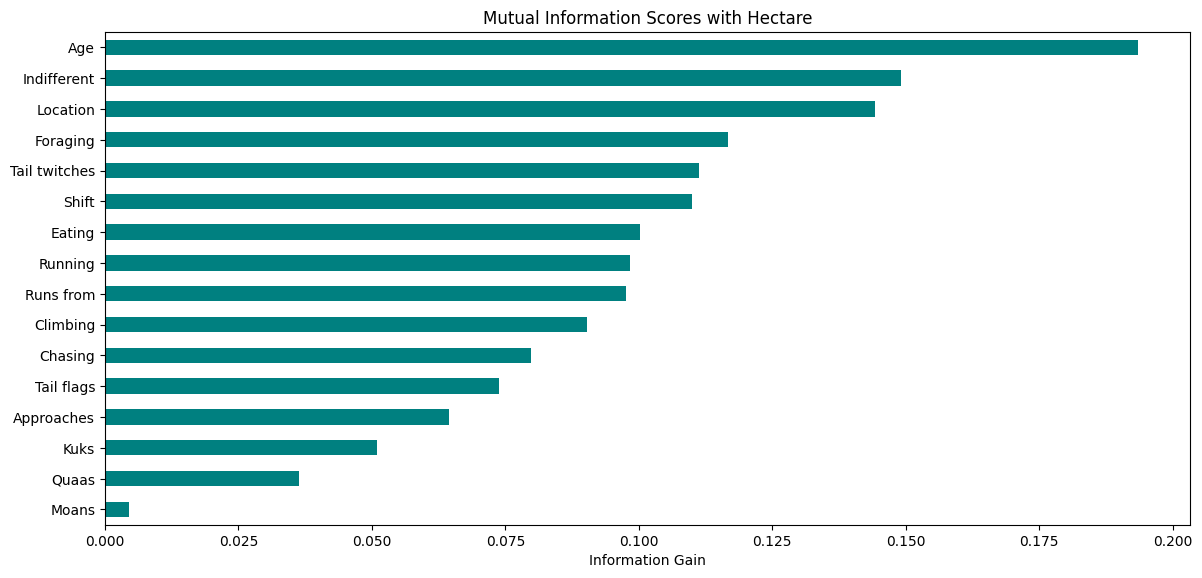

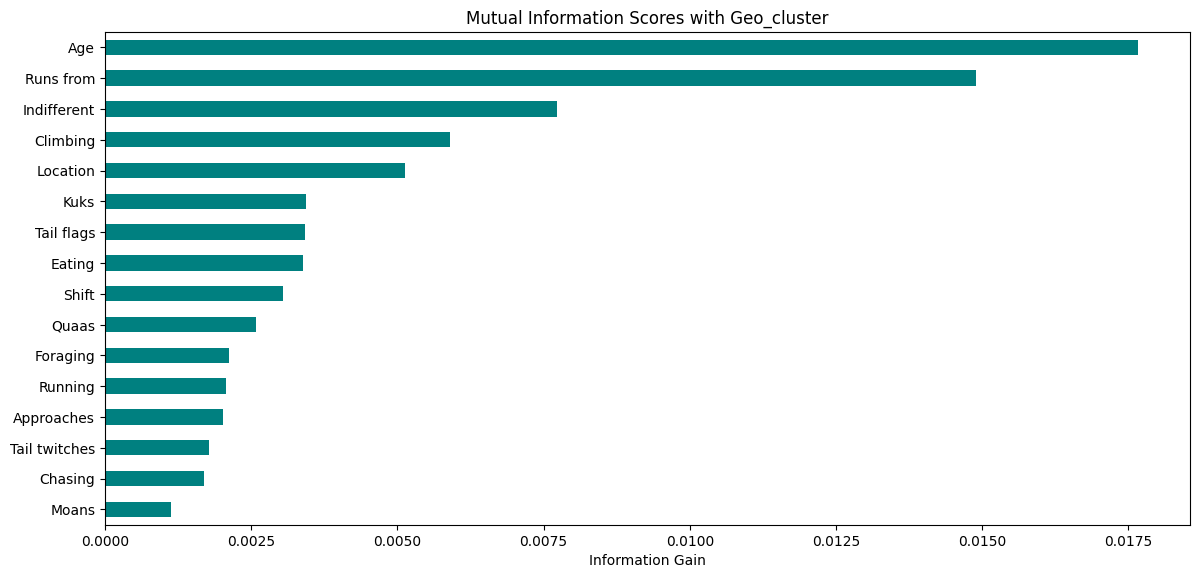

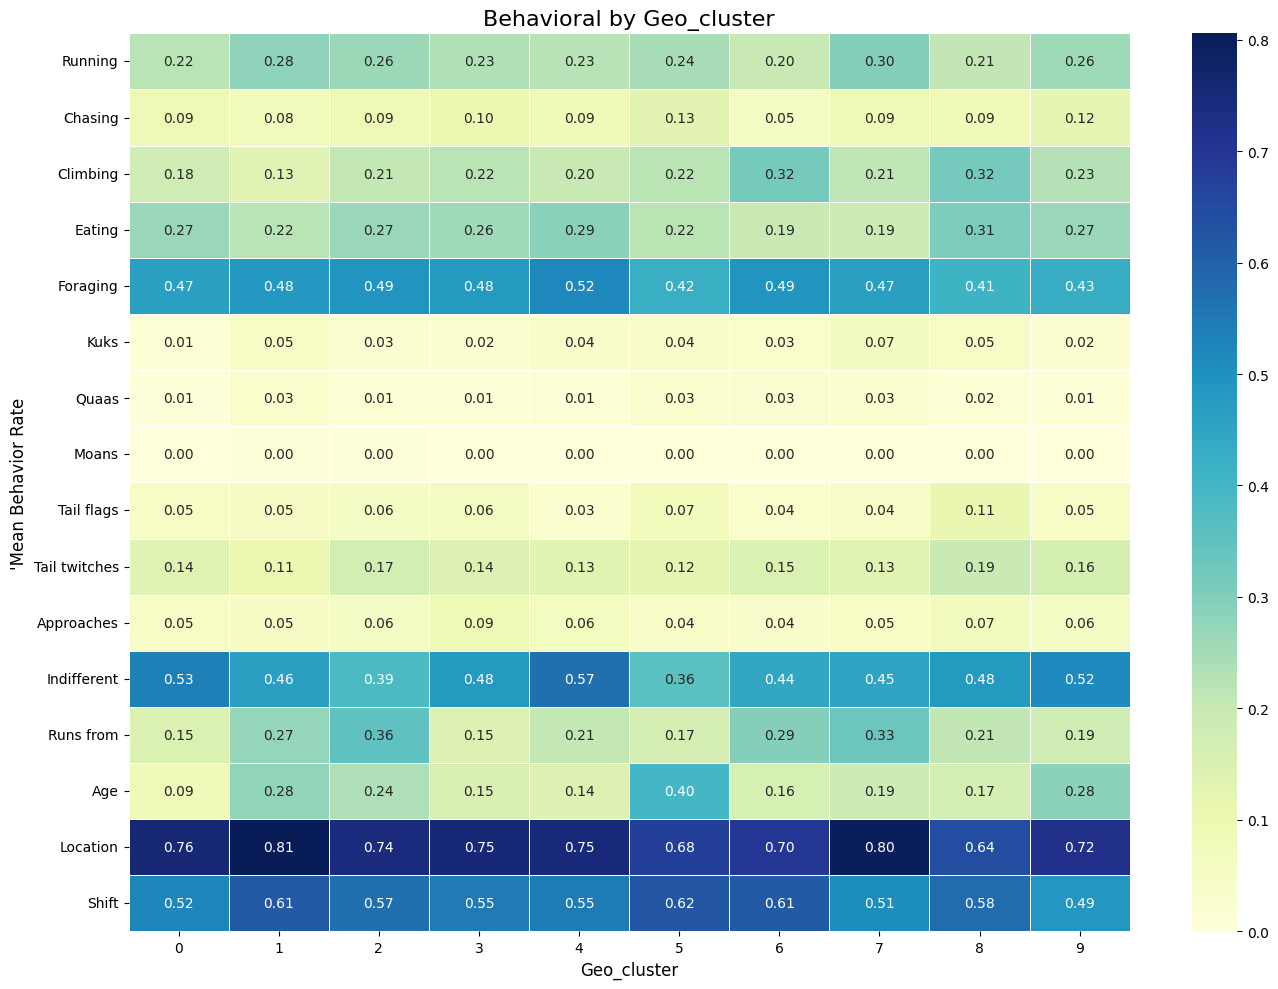

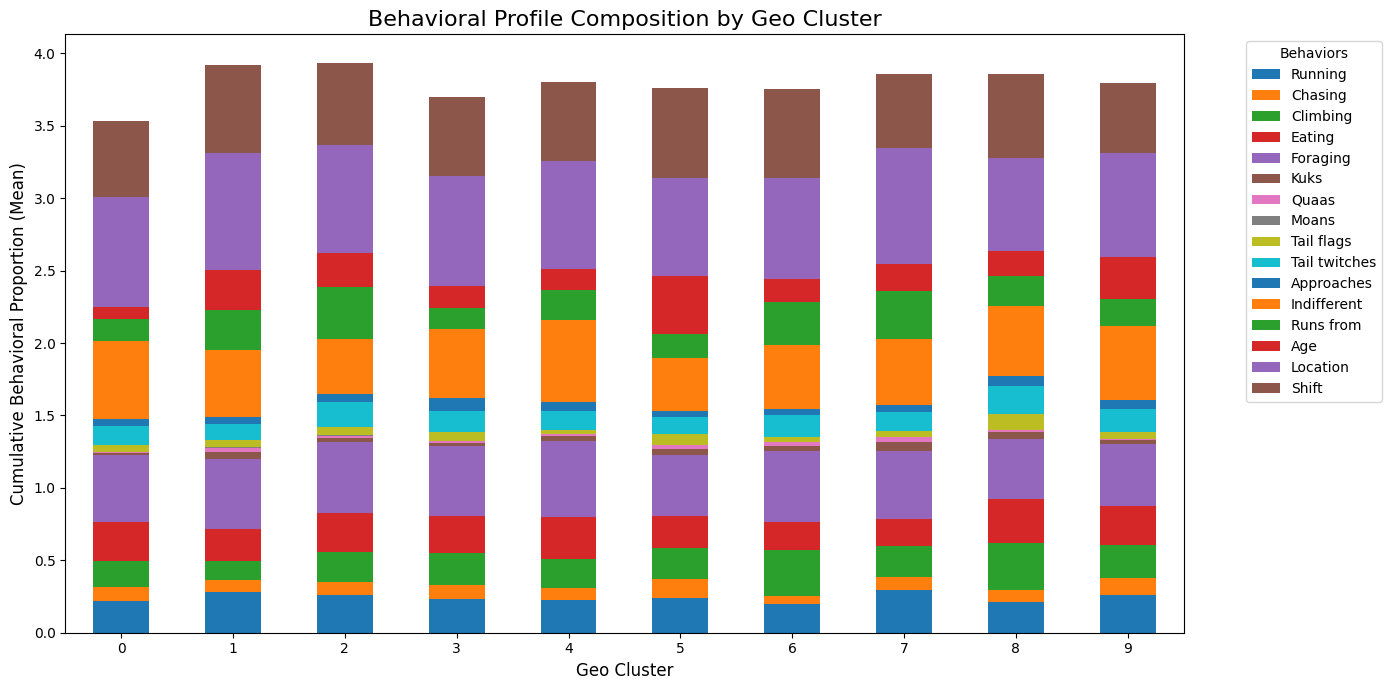

In [295]:
def plot_correlation(df, columns, method='pearson'):
    corr_matrix = df[columns].corr(method=method)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation Matrix ({method.capitalize()})")
    plt.show()

def plot_target_corr(df, features, target, method='pearson'):
    corrs = df[features + [target]].corr(method=method)[target]
    corrs = corrs.drop(index=target).sort_values()

    plt.figure(figsize=(8, len(features) * 0.3))
    colors = ['firebrick' if x < 0 else 'seagreen' for x in corrs]
    corrs.plot(kind='barh', color=colors)
    plt.axvline(0, color='black', lw=1)
    plt.title(f"Correlation with {target} ({method})")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_mutual_information(df, features, target):
    temp_df = df.copy()
    X = temp_df[features]
    y = temp_df[target]
    mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    mi_series = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_series = mi_series.sort_values(ascending=True)

    plt.figure(figsize=(14, len(features) * .4))
    mi_series.plot(kind='barh', color='teal')
    plt.title(f"Mutual Information Scores with {target}")
    plt.xlabel("Information Gain")
    plt.show()

def plot_cluster_behavior_means(df, behavior_cols, cluster_col):
    temp_df = df.copy()
    for col in behavior_cols:
        temp_df[col] = temp_df[col]

    cluster_means = temp_df.groupby(cluster_col)[behavior_cols].mean()

    plot_data = cluster_means.T
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        plot_data,
        annot=True,
        fmt='.2f',
        cmap='YlGnBu',
        linewidths=.5,
    )
    plt.title(f"Behavioral by {cluster_col}", fontsize=16)
    plt.ylabel("'Mean Behavior Rate", fontsize=12)
    plt.xlabel(f"{cluster_col}", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_behavior_stacked_bar(df, behavior_cols, cluster_col):
    cluster_behavior_means = df.groupby(cluster_col)[behavior_cols].mean().sort_index()
    ax = cluster_behavior_means.plot(
        kind='bar',
        stacked=True,
        figsize=(14, 7),
        #colormap='viridis'
    )
    clean_title = cluster_col.replace('_', ' ').title()

    plt.title(f"Behavioral Profile Composition by {clean_title}", fontsize=16)
    plt.xlabel(clean_title, fontsize=12)
    plt.ylabel("Cumulative Behavioral Proportion (Mean)", fontsize=12)

    plt.legend(title="Behaviors", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_behavior_grouped_bar(df, behavior_cols, cluster_col):
    if cluster_col not in df.columns:
        print(f"Error: '{cluster_col}' not found.")
        return

    means = df.groupby(cluster_col)[behavior_cols].mean().reset_index()
    melted_df = means.melt(id_vars=cluster_col, var_name='Behavior', value_name='Proportion')

    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=melted_df,
        x='Behavior',
        y='Proportion',
        hue=cluster_col,
        palette='viridis'
    )

    clean_label = cluster_col.replace('_', ' ').title()
    plt.title(f"Comparison of Behaviors Across {clean_label}", fontsize=16)
    plt.ylabel("Proportion (0.0 - 1.0)", fontsize=12)
    plt.xlabel("Behavioral Category", fontsize=12)
    plt.legend(title=clean_label, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#plot_target_corr(df, behaviour_cols, "X", method="pearson")
plot_target_corr(df, behaviour_cols, "HectareWE", method="pearson")
#plot_target_corr(df, behaviour_cols, "Y", method="pearson")
plot_target_corr(df, behaviour_cols, "HectareSN", method="pearson")

plot_mutual_information(df, behaviour_cols, "Hectare") #non-linear
plot_mutual_information(df, behaviour_cols, "Geo_cluster")
plot_cluster_behavior_means(df, behaviour_cols, "Geo_cluster") #similar
plot_behavior_stacked_bar(df, behaviour_cols, "Geo_cluster")
#plot_behavior_grouped_bar(df, behaviour_cols, "Geo_cluster")

SHAP Analysis

In [296]:
def run_rf_and_shap(train_df, test_df, feature_cols, target):
    X_train = train_df[feature_cols]
    y_train = train_df[target]
    X_test = test_df[feature_cols]

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    shap.plots.bar(shap_values, show=False) #could do better plots
    plt.title(f"SHAP Analysis ({target}): RF")
    plt.tight_layout()
    plt.show()
    return model, shap_values

def run_xgb_and_shap(train_df, test_df, feature_cols, target, lr=0.05):
    X_train = train_df[feature_cols]
    y_train = train_df[target]
    X_test = test_df[feature_cols]

    model = xgb.XGBClassifier(n_estimators=100, random_state=42,
                              learning_rate=lr)
    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    shap.plots.bar(shap_values, show=False)
    plt.title(f"SHAP Analysis ({target}): XGB")
    plt.tight_layout()
    plt.show()
    return model, shap_values

def plot_learning_curve(model, X, y, title="Learning Curve", scoring="accuracy"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="#E74C3C", label="Training Score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#E74C3C")

    plt.plot(train_sizes, test_mean, 'o-', color="#2ECC71", label="Cross-Validation Score")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ECC71")

    plt.title(title, fontsize=14)
    plt.xlabel("Number of Training Samples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#_, shap_vals = run_rf_and_shap(train_df, test_df, behaviour_cols, "Hectare") #non-linear, has directionality, interaction effects
#_, shap_vals = run_rf_and_shap(train_df, test_df, behaviour_cols, "Geo_cluster")

# 2. As a prediction component, we aim to determine whether a squirrel's observed shift (AM or PM) can be predicted from its location and behavioural features.


Feature Engineering

In [297]:
def target_encoding(train, test, cols, target_name, folds=5, smoothing=10):
    train_encoded = train.copy()
    test_encoded = test.copy()
    global_mean = train[target_name].mean()

    for col in cols:
        counts = train.groupby(col)[target_name].count()
        means = train.groupby(col)[target_name].mean()
        mapping = (counts * means + smoothing * global_mean) / (counts + smoothing) #shrinkage
        test_encoded[f'{col}_target_enc'] = test_encoded[col].map(mapping).fillna(global_mean)

        train_encoded[f'{col}_target_enc'] = np.nan
        kf = KFold(n_splits=folds, shuffle=True, random_state=42)
        for train_idx, val_idx in kf.split(train): #using oof means, generalises + prevents leakage
            fold_counts = train.iloc[train_idx].groupby(col)[target_name].count()
            fold_means = train.iloc[train_idx].groupby(col)[target_name].mean()
            fold_mapping = (fold_counts * fold_means + smoothing * global_mean) / (fold_counts + smoothing)
            train_encoded.loc[train_encoded.index[val_idx], f'{col}_target_enc'] = \
                train_encoded.loc[train_encoded.index[val_idx], col].map(fold_mapping)
        train_encoded[f'{col}_target_enc'] = train_encoded[f'{col}_target_enc'].fillna(global_mean)
    return train_encoded, test_encoded

def frequency_encoding(train, test, cols):
    train_encoded = train.copy()
    test_encoded = test.copy()
    for col in cols:
        freq_map = train[col].value_counts(normalize=True).to_dict()
        global_fallback = 0 #ultra rare, 1/len(train)?
        train_encoded[f'{col}_freq_enc'] = train_encoded[col].map(freq_map).fillna(global_fallback)
        test_encoded[f'{col}_freq_enc'] = test_encoded[col].map(freq_map).fillna(global_fallback)
    return train_encoded, test_encoded

def create_cluster_fit(train_df, name, train_data, n=10, ADD=True):
    temp_df = train_df.copy()
    cluster_col_name = f'{name}_cluster'
    km = KMeans(n_clusters=n, n_init=10, random_state=42)
    cluster_labels = km.fit_predict(train_data)
    temp_df[cluster_col_name] = cluster_labels
    km.cluster_counts_ = temp_df[cluster_col_name].value_counts().to_dict()

    if ADD:
        dist_matrix = km.transform(train_data)
        temp_df[f'{name}_dist_to_center'] = dist_matrix[np.arange(len(dist_matrix)), cluster_labels]
        dist_cols = [f'{name}_dist_to_c{i}' for i in range(n)]
        dist_df = pd.DataFrame(dist_matrix, columns=dist_cols, index=temp_df.index)
        temp_df = pd.concat([temp_df, dist_df], axis=1)
        temp_df[f'{name}_cluster_density'] = temp_df[cluster_col_name].map(km.cluster_counts_)
    return temp_df, km

def create_cluster_transform(test_df, name, test_data, km, ADD=True):
    temp_df = test_df.copy()
    cluster_col_name = f'{name}_cluster'
    n = km.n_clusters
    cluster_labels = km.predict(test_data)
    temp_df[cluster_col_name] = cluster_labels

    if ADD:
        dist_matrix = km.transform(test_data)
        temp_df[f'{name}_dist_to_center'] = dist_matrix[np.arange(len(dist_matrix)), cluster_labels]
        dist_cols = [f'{name}_dist_to_c{i}' for i in range(n)]
        dist_df = pd.DataFrame(dist_matrix, columns=dist_cols, index=temp_df.index)
        temp_df = pd.concat([temp_df, dist_df], axis=1)
        temp_df[f'{name}_cluster_density'] = temp_df[cluster_col_name].map(km.cluster_counts_)
    return temp_df

def knn_smoothing_fit(train_df, target_col, smooth_cols, input_cols, k=10, n_splits=5):
    temp_df = train_df.copy()
    all_to_smooth = [target_col] + smooth_cols
    for col in all_to_smooth:
        temp_df[f'knn_smooth_{col}'] = np.nan

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(temp_df):
        df_train_folds = temp_df.iloc[train_idx]
        df_val_fold = temp_df.iloc[val_idx]

        knn_fold = NearestNeighbors(n_neighbors=k)
        knn_fold.fit(df_train_folds[input_cols])
        _, indices = knn_fold.kneighbors(df_val_fold[input_cols]) #OOF KNN target smoothing

        for col in all_to_smooth:
            train_values = df_train_folds[col].values
            smoothed_values = np.mean(train_values[indices], axis=1)
            temp_df.iloc[val_idx, temp_df.columns.get_loc(f'knn_smooth_{col}')] = smoothed_values

    global_knn = NearestNeighbors(n_neighbors=k)
    global_knn.fit(temp_df[input_cols])
    global_knn.train_values_dict_ = {col: temp_df[col].values for col in all_to_smooth} #store original values
    global_knn.k_value_ = k
    global_knn.smooth_cols_ = all_to_smooth
    return temp_df, global_knn

def knn_smoothing_transform(test_df, input_cols, global_knn):
    temp_df = test_df.copy()
    _, indices = global_knn.kneighbors(temp_df[input_cols], n_neighbors=global_knn.k_value_)

    for col in global_knn.smooth_cols_:
        neighbor_values = global_knn.train_values_dict_[col][indices] #uses original as souce of neighbours
        temp_df[f'knn_smooth_{col}'] = np.mean(neighbor_values, axis=1)
    return temp_df

def leaf_embedding_fit(train_df, input_cols, target_col, n_estimators=50, max_depth=4):
    X = train_df[input_cols]
    y = train_df[target_col]

    oof_leaves = np.zeros((len(X), n_estimators))
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    leaf_cols = [f'leaf_tree_{i}' for i in range(n_estimators)]
    for train_idx, val_idx in kf.split(X):
        X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_t = y.iloc[train_idx]
        fold_model = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, verbosity=-1)
        fold_model.fit(X_t, y_t)
        oof_leaves[val_idx, :] = fold_model.predict(X_v, pred_leaf=True) #returns leaf index

    global_model = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, verbosity=-1) #uses all information
    global_model.fit(X, y)
    train_leaf_df = pd.DataFrame(oof_leaves, columns=leaf_cols, index=train_df.index).astype(int)
    return pd.concat([train_df, train_leaf_df], axis=1), global_model

def leaf_embedding_transform(test_df, input_cols, global_model):
    leaf_indices = global_model.predict(test_df[input_cols], pred_leaf=True)
    leaf_cols = [f'leaf_tree_{i}' for i in range(leaf_indices.shape[1])] #1 col per tree
    test_leaf_df = pd.DataFrame(leaf_indices, columns=leaf_cols, index=test_df.index).astype(int)
    return pd.concat([test_df, test_leaf_df], axis=1)

behaviour_cols = list(set(behaviour_cols)-{TARGET})
#train_df["n_behave"] = train_df[behaviour_cols].sum(axis=1)
#test_df["n_behave"] = test_df[behaviour_cols].sum(axis=1)
#train_df["hectare_interaction"] = train_df["HectareWE"] * train_df["HectareSN"] #interaction
#test_df["hectare_interaction"] = test_df["HectareWE"] * train_df["HectareSN"]

scaler = StandardScaler() #faster convergence and same scale for distance-based models
train_df[['X', 'Y']] = scaler.fit_transform(train_df[['X', 'Y']])
test_df[['X', 'Y']] = scaler.transform(test_df[['X', 'Y']])
#train_df, km = create_cluster_fit(train_df, "Geo", train_df[coords], n=15) #fitted only on train to prevent leakage
#test_df = create_cluster_transform(test_df, "Geo", test_df[coords], km)
#train_df, km = create_cluster_fit(train_df, "Behave", train_df[behaviour_cols], n=15)
#test_df = create_cluster_transform(test_df, "Behave", test_df[behaviour_cols], km)
#train_df, global_knn = knn_smoothing_fit(train_df, TARGET, behaviour_cols, input_cols=coords, k=20) #target and feature smoothing
#test_df = knn_smoothing_transform(test_df, input_cols=coords, global_knn=global_knn)
#train_df, global_model = leaf_embedding_fit(train_df, behaviour_cols, TARGET, n_estimators=20) #leaf embeddings (non-linear mapping/coordinates on each tree)
#test_df = leaf_embedding_transform(test_df, behaviour_cols, global_model)

features_to_encode = behaviour_cols+day_cols+["Geo_cluster"]#+["Behave_cluster"]
#train_df, test_df = target_encoding(train_df, test_df, features_to_encode, TARGET) #more info, global context
#train_df, test_df = frequency_encoding(train_df, test_df, features_to_encode) #parse rarity
#dae(only keep predictable part), SVD, time-based, etc?

Relationship Exploration


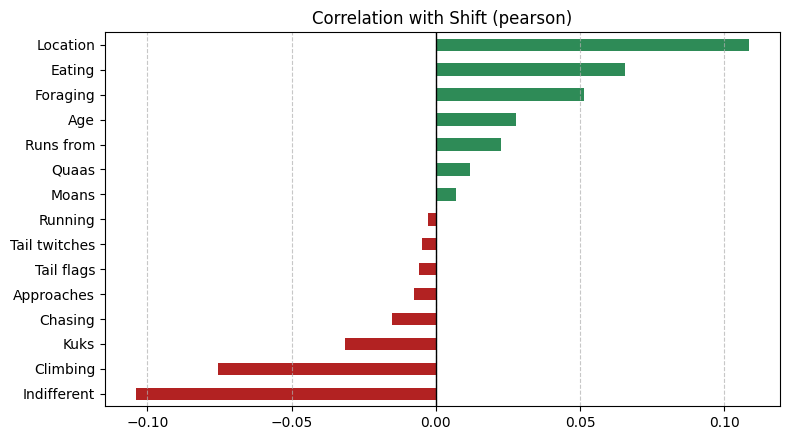

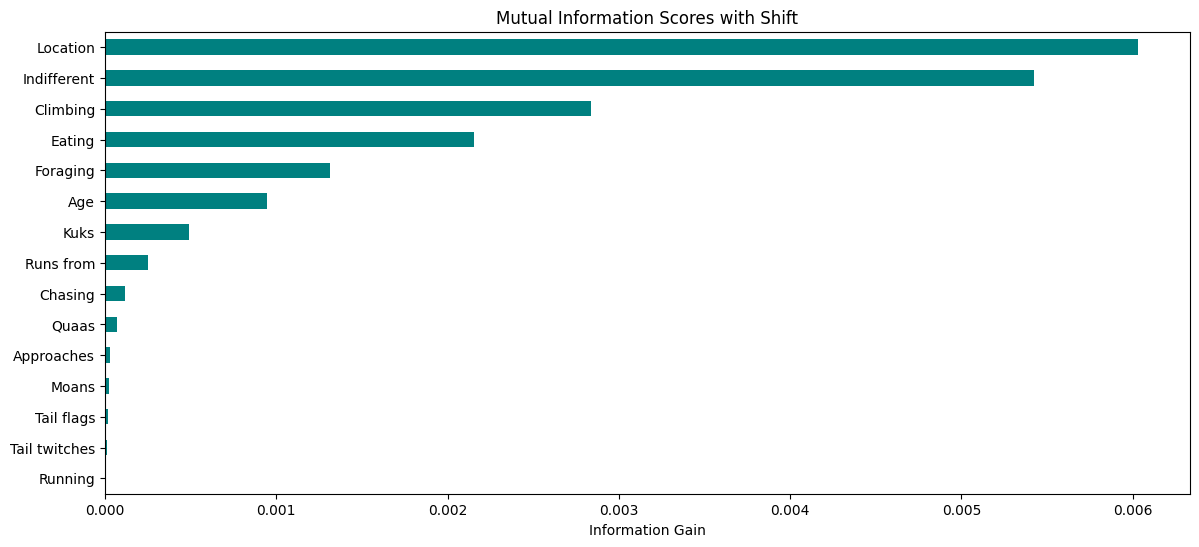

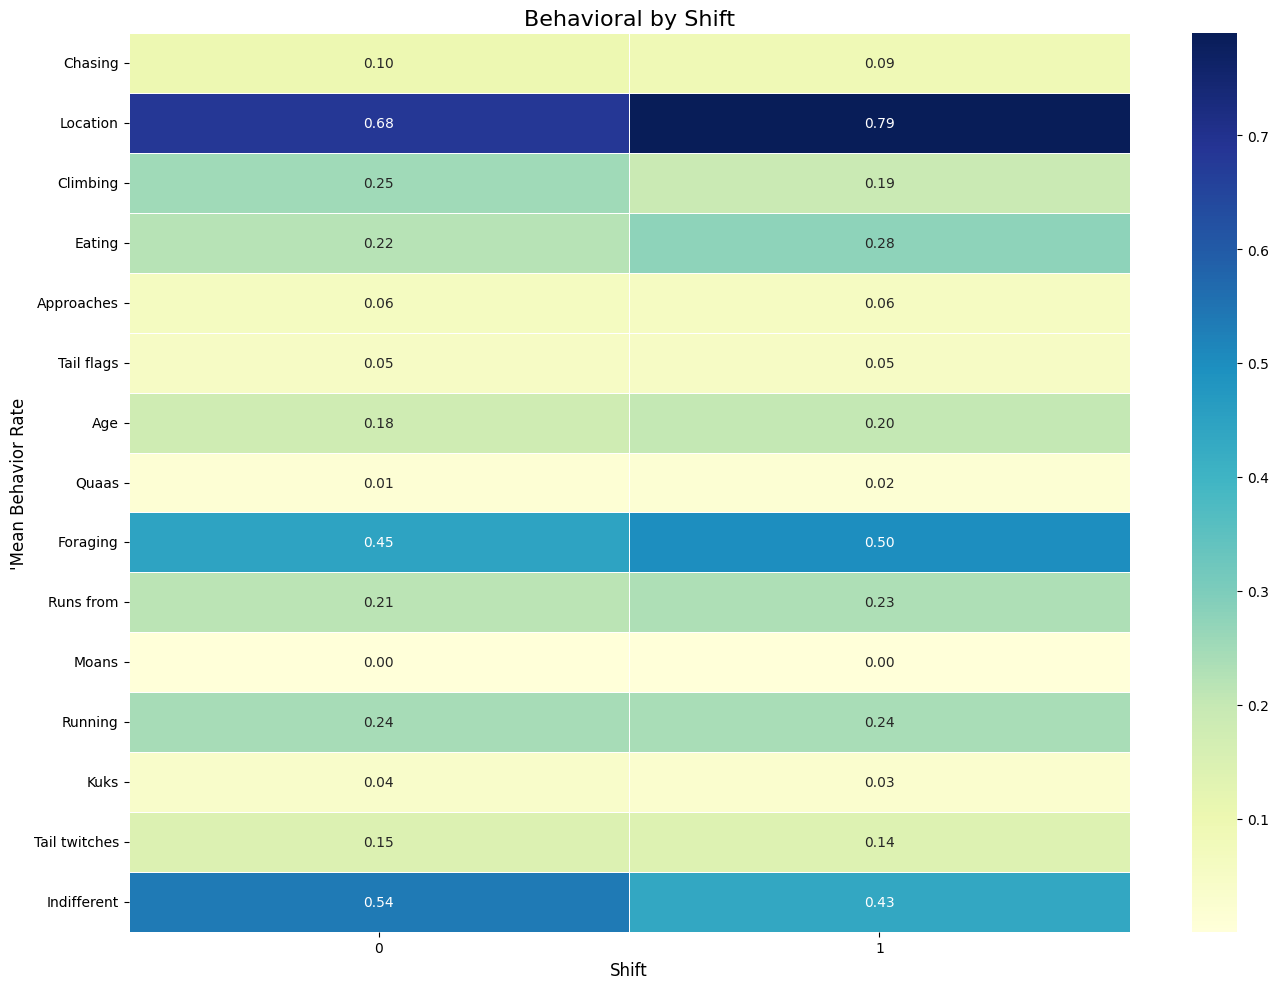

In [298]:
#plot_correlation(df, behaviour_cols+[TARGET])
plot_target_corr(df, behaviour_cols, TARGET, method="pearson") #linear
plot_mutual_information(df, behaviour_cols, TARGET)
plot_cluster_behavior_means(df, behaviour_cols, TARGET)
#plot_behavior_stacked_bar(df, behaviour_cols, TARGET)
#plot_behavior_grouped_bar(df, behaviour_cols, TARGET)

OOF Evaluation

In [299]:
def run_lr_kfold(train_df, test_df, feature_cols, target, n_splits=5, C=1.0, alpha=0.01):
    X = train_df[feature_cols]
    y = train_df[target]
    X_test = test_df[feature_cols]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    models = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
        X_test_fold = X_test.copy()

        #Requires more preprocessing than DT as sensitive to scale and outliers
        lower = X_train.quantile(alpha)
        upper = X_train.quantile(1-alpha)
        X_train = X_train.clip(lower, upper, axis=1)
        X_val = X_val.clip(lower, upper, axis=1)
        X_test_fold = X_test_fold.clip(lower, upper, axis=1)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test_fold)

        model = LogisticRegression(
            C=C,
            max_iter=1000,
            solver='lbfgs',
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)
        models.append(model)
        oof_preds[val_idx] = model.predict_proba(X_val_scaled)[:, 1]
        test_preds += model.predict_proba(X_test_scaled)[:, 1] / n_splits
    return models, oof_preds, test_preds

def run_rf_kfold(train_df, test_df, feature_cols, target, n_splits=5, n_estimators=300):
    X = train_df[feature_cols]
    y = train_df[target]
    X_test = test_df[feature_cols]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    models = []
    for fold, (train_idx, val_idx) in enumerate((skf.split(X, y))):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val = X.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=42 + fold, #different internal logic for each Fold as in parallel
            n_jobs=-1,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1
        )

        model.fit(X_train, y_train)
        models.append(model)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / n_splits
    return models, oof_preds, test_preds

def run_xgb_kfold(train_df, test_df, feature_cols, target, n_splits=5, lr=0.05):
    X = train_df[feature_cols]
    y = train_df[target]
    X_test = test_df[feature_cols]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    models = []
    for fold, (train_idx, val_idx) in enumerate((skf.split(X, y))):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val = X.iloc[val_idx]

        model = xgb.XGBClassifier(
            n_estimators=100,
            learning_rate=lr,
            random_state=42, #standardise as sequential
            eval_metric="logloss"
        )

        model.fit(X_train, y_train)
        models.append(model)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / n_splits
    return models, oof_preds, test_preds


feature_cols = list(set(train_df.columns)-set([TARGET]))
X_train = train_df[feature_cols]
y_train = train_df[TARGET]
y_test = test_df[TARGET]
dead_cols = [c for c in feature_cols if np.isfinite(train_df[c]).sum() == 0] #useless
feature_cols = [c for c in feature_cols if c not in dead_cols]
temp_df = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
f_max = temp_df.max()
f_min = temp_df.min()
train_df[feature_cols] = train_df[feature_cols].replace(np.inf, f_max).replace(-np.inf, f_min).fillna(temp_df.median())
test_df[feature_cols] = test_df[feature_cols].replace(np.inf, f_max).replace(-np.inf, f_min).fillna(temp_df.median()) #lr can't handle -inf and inf
print(f"Features: {feature_cols}")
print(f"Final NaN check: {train_df[feature_cols].isna().sum().sum()}")

#rf_model, shap_vals = run_rf_and_shap(train_df, test_df, feature_cols, TARGET)
#plot_learning_curve(rf_model, X_train, y_train, "Learning Curve (RF)", scoring="roc_auc") #does CV internally
#xgb_model, shap_vals = run_rf_and_shap(train_df, test_df, feature_cols, TARGET)
#plot_learning_curve(xgb_model, X_train, y_train, "Learning Curve (XGB)", scoring="roc_auc")

#DT has can handle complex non-linear patterns, requires less strict assumptions and preprocessing (no scaling required), etc
#StratifiedKFold as maintains class dist, less unstable/dependent on random split and produces oof for stacking, etc (1 model per fold)
#prefered over bootstrapping as full coverage (efficient), less biased/noisy dist, lower risk of leakage, allows stacking/ensemble

#issue of presence of label encoded cols, but probably fine
print("\nLogistic Regression")
lr_model, lr_oof_preds, lr_test_preds = run_lr_kfold(train_df, test_df, feature_cols, TARGET, n_splits=5)
lr_oof_labels = (lr_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, lr_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, lr_oof_preds)*100:.2f}%")

#bagging, reduce variance (less overfit+stable), but high bias (underfit)
print("\nRandom Forest")
rf_model, rf_oof_preds, rf_test_preds = run_rf_kfold(train_df, test_df, feature_cols, TARGET, n_splits=5)
rf_oof_labels = (rf_oof_preds > 0.5).astype(int) #label is threshold dependent
print(f"Accuracy: {accuracy_score(y_train, rf_oof_labels)*100:.2f}%") #bad on imbalanced data (favour majority class)
print(f"ROC_AUC: {roc_auc_score(y_train, rf_oof_preds)*100:.2f}%") #uses prob directly, whereas f1 requires threshold -> ard 0/1 (ignors prob),

#boosting, reduce bias (higher accuracy), but risk of overfit and requires tuning
print("\nXGBoost")
xgb_model, xgb_oof_preds, xgb_test_preds = run_xgb_kfold(train_df, test_df, feature_cols, TARGET, n_splits=5)
xgb_oof_labels = (xgb_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, xgb_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, xgb_oof_preds)*100:.2f}%")
#feature eng, hyperparam tuning w/ val set, tune threshold

Features: ['Y', 'Above Ground Sighter Measurement', 'Climbing', 'HectareSN', 'Eating', 'Hectare', 'Highlight Fur Color', 'Age', 'X_is_missing', 'Foraging', 'Kuks_is_missing', 'Moans', 'Running', 'Indifferent_is_missing', 'Runs from_is_missing', 'Primary Fur Color', 'Tail twitches_is_missing', 'Above Ground Sighter Measurement_is_missing', 'Approaches', 'Indifferent', 'HectareSN_is_missing', 'Moans_is_missing', 'HectareWE_is_missing', 'X', 'HectareWE', 'Chasing', 'Hectare Squirrel Number_is_missing', 'Location', 'Quaas_is_missing', 'Climbing_is_missing', 'Tail flags_is_missing', 'Hectare Squirrel Number', 'Y_is_missing', 'Approaches_is_missing', 'Tail flags', 'Quaas', 'Runs from', 'Chasing_is_missing', 'Running_is_missing', 'Foraging_is_missing', 'Kuks', 'Eating_is_missing', 'Tail twitches']
Final NaN check: 0

Logistic Regression
Accuracy: 56.91%
ROC_AUC: 58.47%

Random Forest
Accuracy: 69.02%
ROC_AUC: 75.45%

XGBoost
Accuracy: 65.47%
ROC_AUC: 70.06%


Final Evaluation

In [300]:
#Majority voting, higher bias
print("\nMajority Voting")
final_preds = (lr_test_preds + rf_test_preds + xgb_test_preds) / 3
final_labels = (final_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, final_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_test, final_preds)*100:.2f}%")

#stacking, higher variance
print("\nStacking")
X_meta = np.column_stack([lr_oof_preds, rf_oof_preds, xgb_oof_preds])
meta_model = LogisticRegression() #combine model preds to make up for their disadv, learn weighting
meta_model.fit(X_meta, y_train) #learn relationship between (oof) model preds and y
X_test_meta = np.column_stack([lr_test_preds, rf_test_preds, xgb_test_preds])
final_preds = meta_model.predict_proba(X_test_meta)[:, 1] #final output (agg from all models)
final_labels = (final_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, final_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_test, final_preds)*100:.2f}%")
#can fit multiple models with differnet types, features, data and hyperparams

#DT has hard coded splits, so risk shifts in feature distribution
#degredation in bagging is smoother as in parallel compared to boosting
#logistic regression degrades even more gracefully as extrapolates
#meta-models may average out drift but also are themselves fragile and exposed to meta-drift


Majority Voting
Accuracy: 68.26%
ROC_AUC: 76.37%

Stacking
Accuracy: 69.92%
ROC_AUC: 79.55%
